# EDA Scope and Research Questions

This notebook performs Exploratory Data Analysis on the cleaned customer churn dataset.
It focuses on descriptive statistics, comparisons, distributions and associations; it does not train a Machine Learning model.

The analysis answers:
1. Which customer segments have higher churn rates?
2. Which behaviors differ between Active and Churned customers?
3. Which numerical variables are associated with churn?

Target definition: `Churned = 0` means Active and `Churned = 1` means Churned.

# Customer Churn Analysis - Exploratory Data Analysis

## 1. Business Problem

## 2. Research Questions

### RQ1 - Who?
Which customer groups have higher churn rates?

### RQ2 - What?
Which customer behaviors are associated with churn?

## 3. Dataset Overview

## 4. Data Loading

## 5. Data Quality Check
### 5.1 Data Types
### 5.2 Missing Values
### 5.3 Duplicate Values
### 5.4 Unique Values

## 6. Target Variable Analysis
### 6.1 Churn Distribution
### 6.2 Churn Rate

## 7. Demographic Analysis
### 7.1 Gender
### 7.2 Country
### 7.3 Age
### 7.4 Membership Years

## 8. Customer Engagement Analysis
### 8.1 Login Frequency
### 8.2 Session Duration
### 8.3 Pages Per Session
### 8.4 Email Open Rate
### 8.5 Mobile App Usage
### 8.6 Social Media Engagement

## 9. Purchase Behavior Analysis
### 9.1 Total Purchases
### 9.2 Average Order Value
### 9.3 Days Since Last Purchase
### 9.4 Cart Abandonment Rate
### 9.5 Discount Usage Rate
### 9.6 Returns Rate

## 10. Customer Service Analysis
### 10.1 Customer Service Calls
### 10.2 Product Reviews

## 11. Financial Analysis
### 11.1 Lifetime Value
### 11.2 Credit Balance

## 12. Correlation Analysis

## 13. Outlier Analysis

## 14. Key EDA Findings

## 15. Conclusion

Câu 1: Churn rate hiện tại là bao nhiêu?

Câu 2: Nhóm demographic nào có churn cao?

Country
Gender
Age Group
Membership Group

Câu 3: Khách hàng churn có hành vi engagement như thế nào?

Login
Session
Pages
Email
Mobile
Social Media

Câu 4: Khách hàng churn có hành vi mua hàng như thế nào?

Purchases
Recency
Cart Abandonment
Returns
Discount
AOV

Câu 5: Feature nào có mối liên hệ mạnh với Churned?

Correlation

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [65]:
df = pd.read_csv(
    "D:/Desktop/Projects/customer-churn-analytics/data/processed/customer_churn_clean.csv"
)

df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## Dataset Overview

EDA uses the cleaned dataset as input. The following outputs describe the dataset structure without performing data cleaning.

In [94]:
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
display(pd.DataFrame({"Column": df.columns}))
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))
print("\nNumerical summary:")
display(df.describe().T)
print("\nCategorical summary:")
display(df.describe(include="str").T)

Dataset shape: (50000, 27)

Column names:


,Column
0,Age
1,Gender
2,Country
3,City
4,Membership_Years
5,Login_Frequency
6,Session_Duration_Avg
7,Pages_Per_Session
8,Cart_Abandonment_Rate
9,Wishlist_Items



Data types:


,Data Type
Age,float64
Gender,str
Country,str
City,str
Membership_Years,float64
Login_Frequency,float64
Session_Duration_Avg,float64
Pages_Per_Session,float64
Cart_Abandonment_Rate,float64
Wishlist_Items,float64



Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Age,50000.0,37.775400,11.156026,18.00,30.0000,38.000,45.00,75.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,50000.0,27.602240,10.497234,1.00,20.2000,26.800,34.00,75.600000
Pages_Per_Session,50000.0,8.717542,3.663996,1.00,6.2000,8.400,11.00,24.100000
Cart_Abandonment_Rate,50000.0,57.043036,16.206917,0.00,46.4000,58.100,68.70,100.000000
Wishlist_Items,50000.0,4.274520,3.060573,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.126160,6.995480,0.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,50000.0,29.265300,28.866043,0.00,9.0000,21.000,39.00,287.000000



Categorical summary:


,count,unique,top,freq
Gender,50000,3,Female,25116
Country,50000,8,USA,17384
City,50000,40,Houston,3549
Signup_Quarter,50000,4,Q3,12558


## 6. Target Variable Analysis
### 6.1 Churn Distribution

In [28]:
churn_count = df["Churned"].value_counts()

print(churn_count)

Churned
0    35550
1    14450
Name: count, dtype: int64


### 6.2 Churn Rate

In [29]:
churn_rate = df["Churned"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 28.90%


Total Customers: 50000
Active Customers: 35550
Churned Customers: 14450
Churn Rate: 28.90%
Active Rate: 71.10%


,Customer Status,Count,Rate (%)
0,Active,35550,71.1
1,Churned,14450,28.9


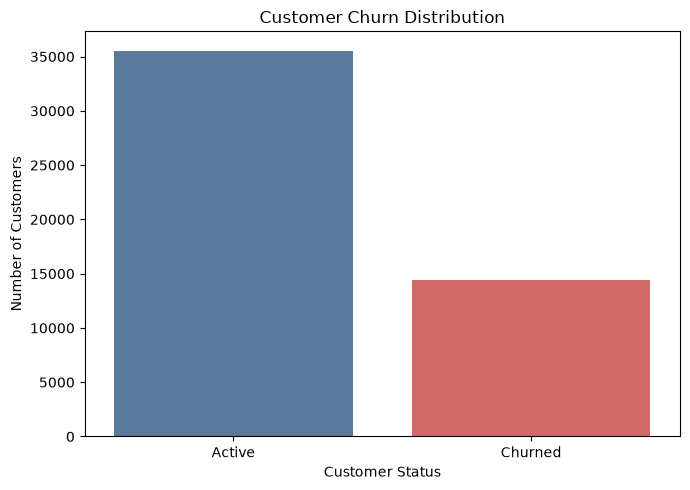

In [86]:
target_summary = pd.DataFrame({
    "Customer Status": ["Active", "Churned"],
    "Count": [
        int((df["Churned"] == 0).sum()),
        int((df["Churned"] == 1).sum())
    ],
    "Rate (%)": [
        round((df["Churned"] == 0).mean() * 100, 2),
        round((df["Churned"] == 1).mean() * 100, 2)
    ]
})

total_customers = len(df)
active_customers = int((df["Churned"] == 0).sum())
churned_customers = int((df["Churned"] == 1).sum())
active_rate = active_customers / total_customers * 100

print(f"Total Customers: {total_customers}")
print(f"Active Customers: {active_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Churn Rate: {churned_customers / total_customers * 100:.2f}%")
print(f"Active Rate: {active_rate:.2f}%")
display(target_summary)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=target_summary,
    x="Customer Status",
    y="Count",
    hue="Customer Status",
    palette=["#4C78A8", "#E45756"],
    legend=False
 )
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

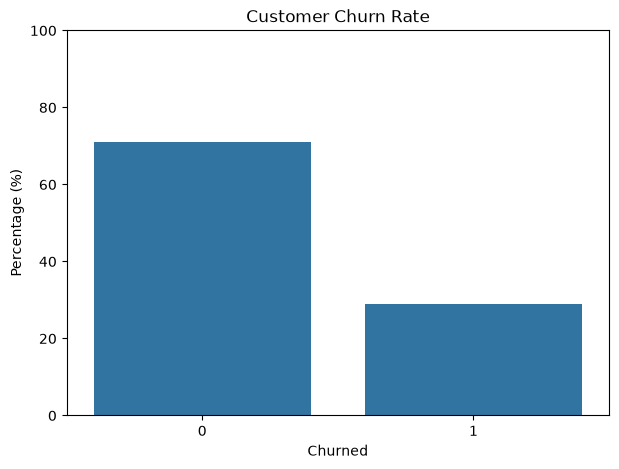

In [30]:
churn_pct = df["Churned"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_pct.index,
    y=churn_pct.values
)

plt.title("Customer Churn Rate")
plt.xlabel("Churned")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

plt.show()

## 7. Demographic Analysis
### 7.1 Country


In [66]:
country_churn = (
    df.assign(Customer_Count=1)
      .pivot_table(
          index="Country",
          columns="Churned",
          values="Customer_Count",
          aggfunc="sum",
          fill_value=0
      )
      .rename(columns={
          0: "Churn_0",
          1: "Churn_1"
      })
      .reset_index()
 )

for column in ["Churn_0", "Churn_1"]:
    if column not in country_churn.columns:
        country_churn[column] = 0

country_churn["Total"] = (
    country_churn["Churn_0"] +
    country_churn["Churn_1"]
)

country_churn["Churn_Rate (%)"] = (
    country_churn["Churn_1"] /
    country_churn["Total"] * 100
).round(2)

country_churn = country_churn.sort_values(
    "Churn_Rate (%)",
    ascending=False
)

print("Bảng count Churn 0/1 và churn rate theo quốc gia:")
display(country_churn)

highest_churn_country = country_churn.iloc[0]
print(
    f"Quốc gia có churn rate cao nhất: {highest_churn_country['Country']} "
    f"({highest_churn_country['Churn_Rate (%)']:.2f}%)"
 )

Bảng count Churn 0/1 và churn rate theo quốc gia:


Churned,Country,Churn_0,Churn_1,Total,Churn_Rate (%)
0,Australia,2847,1214,4061,29.89
1,Canada,4255,1768,6023,29.35
7,USA,12328,5056,17384,29.08
4,India,2493,1019,3512,29.01
3,Germany,3505,1420,4925,28.83
6,UK,5365,2169,7534,28.79
5,Japan,1839,709,2548,27.83
2,France,2918,1095,4013,27.29


Quốc gia có churn rate cao nhất: Australia (29.89%)


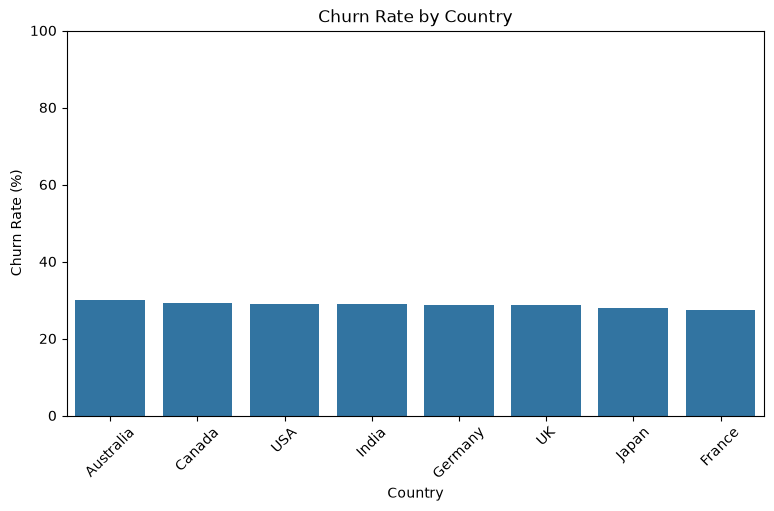

In [58]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=country_churn,
    x="Country",
    y="Churn_Rate (%)"
 )

plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()

### 7.2 Gender

In [67]:
gender_churn = (
    df.assign(Customer_Count=1)
      .pivot_table(
          index="Gender",
          columns="Churned",
          values="Customer_Count",
          aggfunc="sum",
          fill_value=0
      )
      .rename(columns={
          0: "Churn_0",
          1: "Churn_1"
      })
      .reset_index()
 )

for column in ["Churn_0", "Churn_1"]:
    if column not in gender_churn.columns:
        gender_churn[column] = 0

gender_churn["Total"] = (
    gender_churn["Churn_0"] +
    gender_churn["Churn_1"]
 )

gender_churn["Churn_Rate (%)"] = (
    gender_churn["Churn_1"] /
    gender_churn["Total"] * 100
 ).round(2)

gender_churn = gender_churn.sort_values(
    "Churn_Rate (%)",
    ascending=False
 )

print("Bảng count Churn 0/1 và churn rate theo giới tính:")
display(gender_churn)

Bảng count Churn 0/1 và churn rate theo giới tính:


Churned,Gender,Churn_0,Churn_1,Total,Churn_Rate (%)
2,Other,644,293,937,31.27
0,Female,17839,7277,25116,28.97
1,Male,17067,6880,23947,28.73


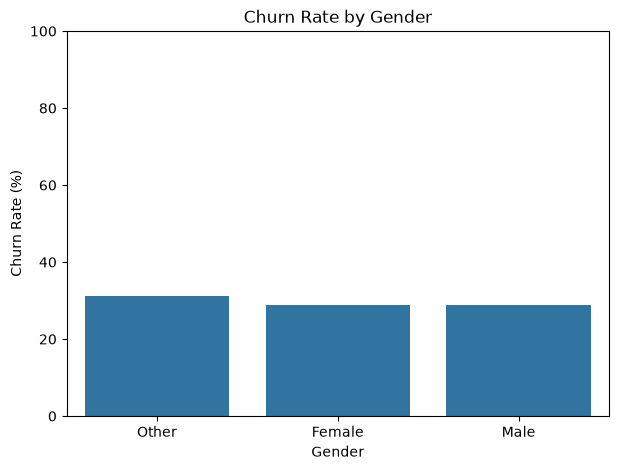

In [61]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn,
    x="Gender",
    y="Churn_Rate (%)"
 )

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

plt.show()

### 7.3 Age

In [ ]:
bins = [0, 25, 35, 45, 55, float("inf")]

labels = [
    "<=25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

age_churn = (
    df.groupby(["Age_Group", "Churned"], observed=False)
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

age_churn = age_churn.rename(columns={
    0: "Churn_0",
    1: "Churn_1"
})

age_churn["Total"] = (
    age_churn["Churn_0"] +
    age_churn["Churn_1"]
)

age_churn["Churn_Rate (%)"] = (
    age_churn["Churn_1"] /
    age_churn["Total"] * 100
).round(2)

age_churn

Churned,Age_Group,Churn_0,Churn_1,Total,Churn_Rate (%)
0,<=25,4094,3417,7511,45.49
1,26-35,9596,3453,13049,26.46
2,36-45,12980,4422,17402,25.41
3,46-55,6526,2308,8834,26.13
4,56+,2354,850,3204,26.53


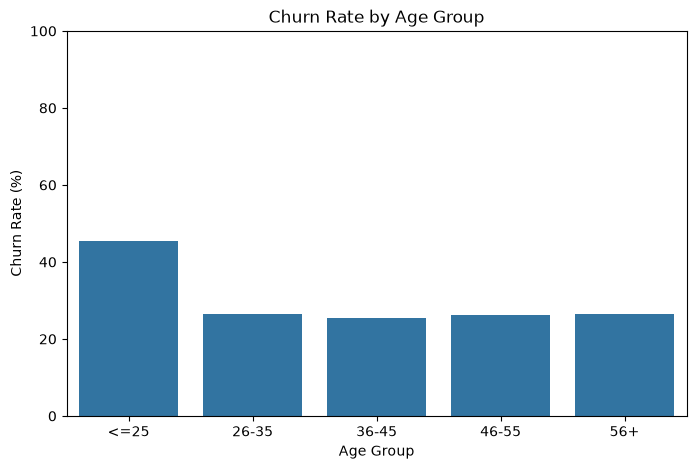

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_churn,
    x="Age_Group",
    y="Churn_Rate (%)"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

plt.show()

In [92]:
highest_age_group = age_churn.loc[age_churn["Churn_Rate (%)"].idxmax()]
lowest_age_group = age_churn.loc[age_churn["Churn_Rate (%)"].idxmin()]
highest_country = country_churn.iloc[0]
lowest_country = country_churn.iloc[-1]
highest_gender_row = gender_churn.iloc[0]
lowest_gender_row = gender_churn.iloc[-1]

print(
    f"Highest-risk age group: {highest_age_group['Age_Group']} "
    f"({highest_age_group['Churn_Rate (%)']:.2f}%)"
 )
print(
    f"Lowest-risk age group: {lowest_age_group['Age_Group']} "
    f"({lowest_age_group['Churn_Rate (%)']:.2f}%)"
 )
print(
    f"Highest-risk country: {highest_country['Country']} "
    f"({highest_country['Churn_Rate (%)']:.2f}%)"
 )
print(
    f"Lowest-risk country: {lowest_country['Country']} "
    f"({lowest_country['Churn_Rate (%)']:.2f}%)"
 )
print(
    f"Highest-risk gender: {highest_gender_row['Gender']} "
    f"({highest_gender_row['Churn_Rate (%)']:.2f}%)"
 )
print(
    f"Lowest-risk gender: {lowest_gender_row['Gender']} "
    f"({lowest_gender_row['Churn_Rate (%)']:.2f}%)"
 )

Highest-risk age group: <=25 (45.49%)
Lowest-risk age group: 36-45 (25.41%)
Highest-risk country: Australia (29.89%)
Lowest-risk country: France (27.29%)
Highest-risk gender: Other (31.27%)
Lowest-risk gender: Male (28.73%)


### 7.4 Membership Years

In [69]:
max_year = int(np.ceil(df["Membership_Years"].max()))

bins = np.arange(0, max_year + 2, 1)
labels = [f"{i}-{i+1} năm" for i in range(max_year + 1)]

df["Membership_Group"] = pd.cut(
    df["Membership_Years"],
    bins=bins,
    labels=labels,
    right=False
)

membership_yearly_summary = (
    df.groupby(["Membership_Group", "Churned"], observed=False)
      .size()
      .unstack(fill_value=0)
      .rename(columns={
          0: "Churn_0",
          1: "Churn_1"
      })
 )

for column in ["Churn_0", "Churn_1"]:
    if column not in membership_yearly_summary.columns:
        membership_yearly_summary[column] = 0

membership_yearly_summary["Total"] = (
    membership_yearly_summary["Churn_0"] +
    membership_yearly_summary["Churn_1"]
 )

membership_yearly_summary["Churn_Rate (%)"] = (
    membership_yearly_summary["Churn_1"] /
    membership_yearly_summary["Total"] * 100
 ).round(2)

membership_yearly_summary = membership_yearly_summary[
    ["Churn_0", "Churn_1", "Total", "Churn_Rate (%)"]
 ]

print("Bảng count Churn 0/1, tổng số lượng và churn rate theo số năm thành viên:")
display(membership_yearly_summary)

Bảng count Churn 0/1, tổng số lượng và churn rate theo số năm thành viên:


Churned,Churn_0,Churn_1,Total,Churn_Rate (%)
Membership_Group,,,,
0-1 năm,4826,1941,6767,28.68
1-2 năm,8516,3391,11907,28.48
2-3 năm,7474,3120,10594,29.45
3-4 năm,5403,2244,7647,29.34
4-5 năm,3664,1477,5141,28.73
5-6 năm,2286,938,3224,29.09
6-7 năm,1426,552,1978,27.91
7-8 năm,821,340,1161,29.29
8-9 năm,481,185,666,27.78


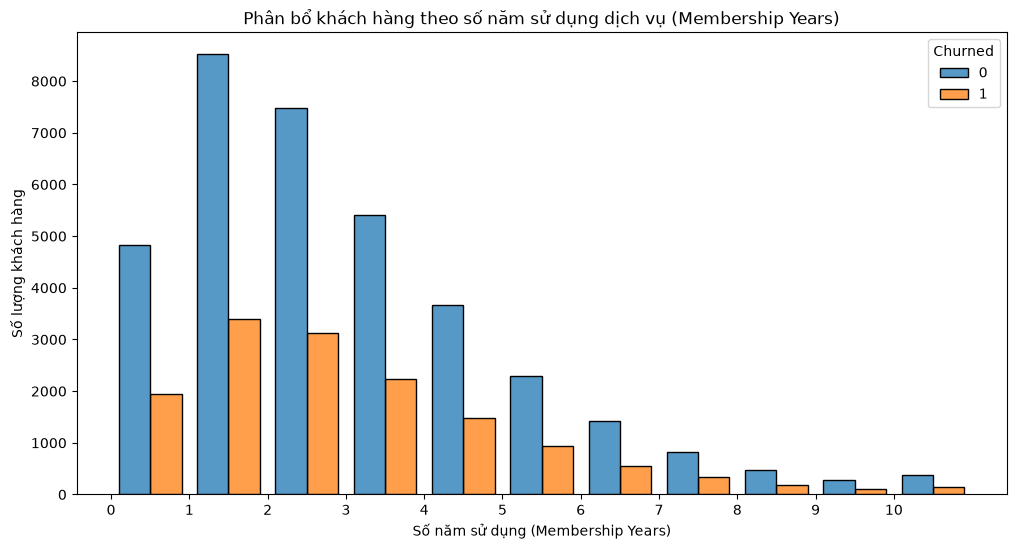

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Membership_Years",
    hue="Churned",
    multiple="dodge",  
    bins=range(0, int(df["Membership_Years"].max()) + 2), 
    shrink=0.8         
)

plt.title("Phân bổ khách hàng theo số năm sử dụng dịch vụ (Membership Years)")
plt.xlabel("Số năm sử dụng (Membership Years)")
plt.ylabel("Số lượng khách hàng")

plt.xticks(range(0, int(df["Membership_Years"].max()) + 1)) 

plt.show()

## 8. Customer Engagement Analysis

Các chỉ số được so sánh giữa hai nhóm:
- Active: `Churned = 0`
- Churned: `Churned = 1`

Mục tiêu là xác định hành vi engagement khác biệt rõ nhất giữa hai nhóm.

In [43]:
behavior_features = [
    "Login_Frequency",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Cart_Abandonment_Rate",
    "Wishlist_Items",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Returns_Rate",
    "Email_Open_Rate",
    "Customer_Service_Calls",
    "Product_Reviews_Written",
    "Social_Media_Engagement_Score",
    "Mobile_App_Usage",
    "Payment_Method_Diversity",
    "Lifetime_Value",
    "Credit_Balance"
]

In [44]:
behavior_summary = df.groupby("Churned")[behavior_features].mean().T

behavior_summary.columns = ["Active", "Churned"]

behavior_summary["Difference"] = (
    behavior_summary["Churned"]
    - behavior_summary["Active"]
)

behavior_summary

,Active,Churned,Difference
Login_Frequency,12.642391,9.120830,-3.521561
Session_Duration_Avg,29.071314,23.988014,-5.083300
Pages_Per_Session,9.242450,7.426159,-1.816291
Cart_Abandonment_Rate,54.155429,64.147149,9.991720
Wishlist_Items,4.644416,3.364498,-1.279918
Total_Purchases,13.844037,11.360035,-2.484002
Average_Order_Value,118.383907,134.762532,16.378625
Days_Since_Last_Purchase,26.541322,35.966851,9.425529
Discount_Usage_Rate,42.568862,39.196484,-3.372377
Returns_Rate,6.374477,7.036706,0.662229


In [84]:
behavior_summary.sort_values(
    "Difference",
    key=abs,
    ascending=False
)

,Active,Churned,Difference
Credit_Balance,2067.570408,1690.190450,-377.379958
Lifetime_Value,1446.805875,1425.423236,-21.382639
Average_Order_Value,118.383907,134.762532,16.378625
Cart_Abandonment_Rate,54.155429,64.147149,9.991720
Days_Since_Last_Purchase,26.541322,35.966851,9.425529
Social_Media_Engagement_Score,31.366447,23.706526,-7.659921
Email_Open_Rate,22.790262,16.164401,-6.625860
Session_Duration_Avg,29.071314,23.988014,-5.083300
Mobile_App_Usage,20.499060,16.330844,-4.168216
Login_Frequency,12.642391,9.120830,-3.521561


## Active vs Churned Comparison

This section consolidates all behavioral, service and financial features into one comparison table.

Active vs Churned comparison:


,Active Mean,Churned Mean,Difference,Absolute Difference
Credit_Balance,2067.570408,1690.190450,-377.38,377.38
Lifetime_Value,1446.805875,1425.423236,-21.38,21.38
Average_Order_Value,118.383907,134.762532,16.38,16.38
Cart_Abandonment_Rate,54.155429,64.147149,9.99,9.99
Days_Since_Last_Purchase,26.541322,35.966851,9.43,9.43
Social_Media_Engagement_Score,31.366447,23.706526,-7.66,7.66
Email_Open_Rate,22.790262,16.164401,-6.63,6.63
Session_Duration_Avg,29.071314,23.988014,-5.08,5.08
Mobile_App_Usage,20.499060,16.330844,-4.17,4.17
Login_Frequency,12.642391,9.120830,-3.52,3.52


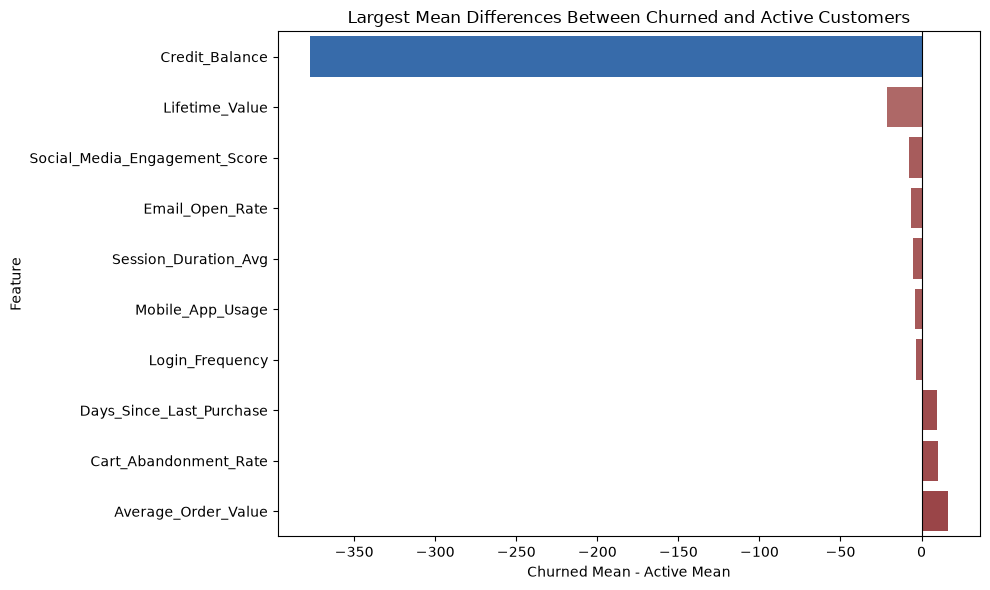

In [89]:
comparison_features = behavior_features

active_vs_churned = df.groupby("Churned")[comparison_features].mean().T
active_vs_churned.columns = ["Active Mean", "Churned Mean"]
active_vs_churned["Difference"] = (
    active_vs_churned["Churned Mean"] - active_vs_churned["Active Mean"]
 ).round(2)
active_vs_churned["Absolute Difference"] = active_vs_churned["Difference"].abs().round(2)
active_vs_churned = active_vs_churned.sort_values(
    "Absolute Difference",
    ascending=False
 )

print("Active vs Churned comparison:")
display(active_vs_churned)

top_difference = active_vs_churned.head(10).sort_values("Difference")
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_difference.reset_index(),
    x="Difference",
    y="index",
    hue="Difference",
    palette="vlag",
    legend=False
 )
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Largest Mean Differences Between Churned and Active Customers")
plt.xlabel("Churned Mean - Active Mean")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

So sánh hành vi engagement giữa Active và Churned:


,Active,Churned,Difference
Social_Media_Engagement_Score,31.366447,23.706526,-7.66
Email_Open_Rate,22.790262,16.164401,-6.63
Session_Duration_Avg,29.071314,23.988014,-5.08
Mobile_App_Usage,20.499060,16.330844,-4.17
Login_Frequency,12.642391,9.120830,-3.52
Pages_Per_Session,9.242450,7.426159,-1.82


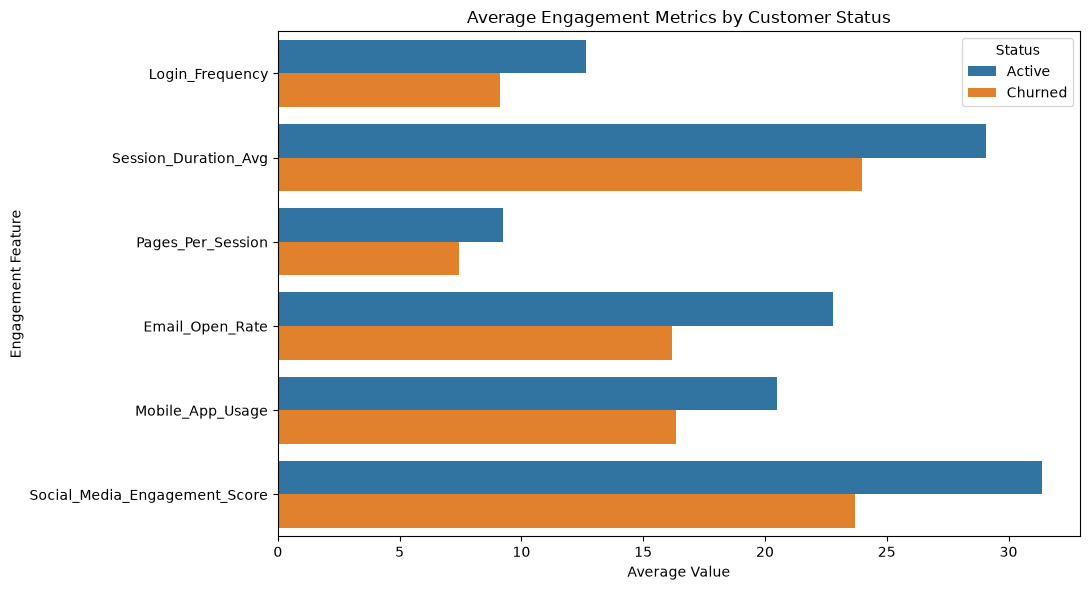

In [70]:
engagement_features = [
    "Login_Frequency",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Email_Open_Rate",
    "Mobile_App_Usage",
    "Social_Media_Engagement_Score"
 ]

engagement_summary = df.groupby("Churned")[engagement_features].mean().T
engagement_summary.columns = ["Active", "Churned"]
engagement_summary["Difference"] = (
    engagement_summary["Churned"] - engagement_summary["Active"]
 ).round(2)

print("So sánh hành vi engagement giữa Active và Churned:")
display(engagement_summary.sort_values("Difference", key=abs, ascending=False))

engagement_plot = engagement_summary[["Active", "Churned"]].reset_index()
engagement_plot = engagement_plot.rename(columns={"index": "Feature"})
engagement_plot = engagement_plot.melt(
    id_vars="Feature",
    var_name="Customer Status",
    value_name="Average Value"
 )

plt.figure(figsize=(11, 6))
sns.barplot(
    data=engagement_plot,
    x="Average Value",
    y="Feature",
    hue="Customer Status"
 )
plt.title("Average Engagement Metrics by Customer Status")
plt.xlabel("Average Value")
plt.ylabel("Engagement Feature")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

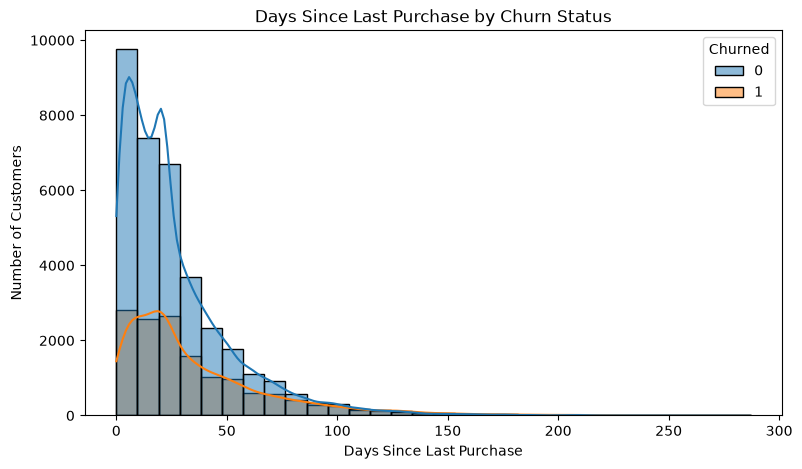

In [48]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Days_Since_Last_Purchase",
    hue="Churned",
    kde=True,
    bins=30
)

plt.title("Days Since Last Purchase by Churn Status")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

## 9. Purchase Behavior Analysis

Phần này so sánh hành vi mua hàng giữa khách hàng Active và Churned.

So sánh hành vi mua hàng giữa Active và Churned:


,Active,Churned,Difference
Average_Order_Value,118.383907,134.762532,16.38
Cart_Abandonment_Rate,54.155429,64.147149,9.99
Days_Since_Last_Purchase,26.541322,35.966851,9.43
Discount_Usage_Rate,42.568862,39.196484,-3.37
Total_Purchases,13.844037,11.360035,-2.48
Returns_Rate,6.374477,7.036706,0.66


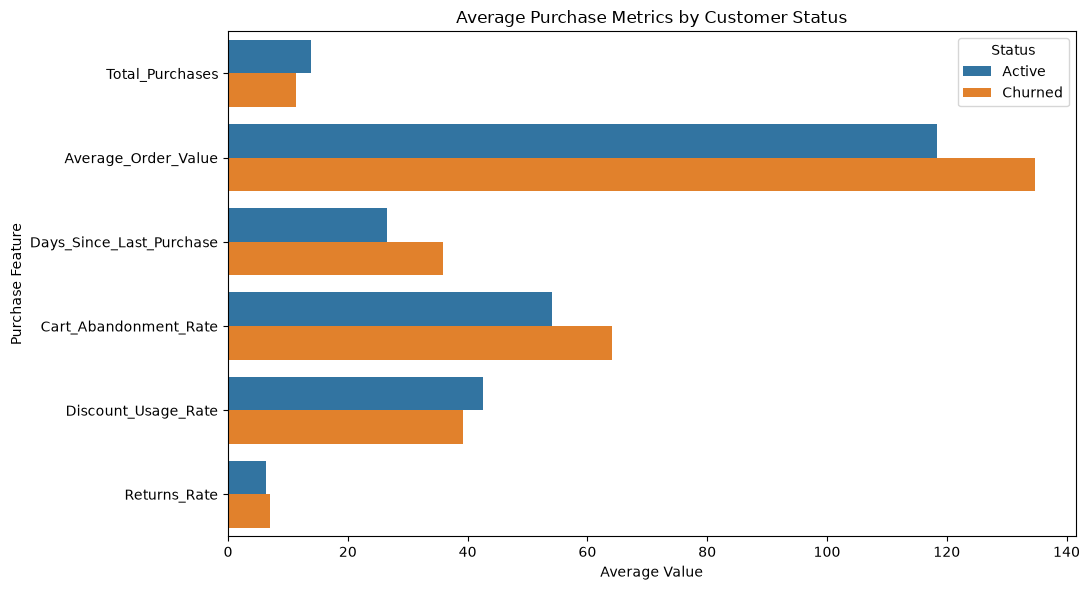

In [82]:
purchase_features = [
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Cart_Abandonment_Rate",
    "Discount_Usage_Rate",
    "Returns_Rate"
 ]

purchase_summary = df.groupby("Churned")[purchase_features].mean().T
purchase_summary.columns = ["Active", "Churned"]
purchase_summary["Difference"] = (
    purchase_summary["Churned"] - purchase_summary["Active"]
 ).round(2)

print("So sánh hành vi mua hàng giữa Active và Churned:")
display(purchase_summary.sort_values("Difference", key=abs, ascending=False))

purchase_plot = purchase_summary[["Active", "Churned"]].reset_index()
purchase_plot = purchase_plot.rename(columns={"index": "Feature"})
purchase_plot = purchase_plot.melt(
    id_vars="Feature",
    var_name="Customer Status",
    value_name="Average Value"
 )

plt.figure(figsize=(11, 6))
sns.barplot(
    data=purchase_plot,
    x="Average Value",
    y="Feature",
    hue="Customer Status"
 )
plt.title("Average Purchase Metrics by Customer Status")
plt.xlabel("Average Value")
plt.ylabel("Purchase Feature")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

## 10. Customer Service Analysis

Phân tích số cuộc gọi hỗ trợ và số lượng đánh giá sản phẩm theo trạng thái churn.

So sánh chỉ số chăm sóc khách hàng giữa Active và Churned:


,Active,Churned,Difference
Customer_Service_Calls,5.184895,6.896471,1.71
Product_Reviews_Written,3.044557,2.176125,-0.87


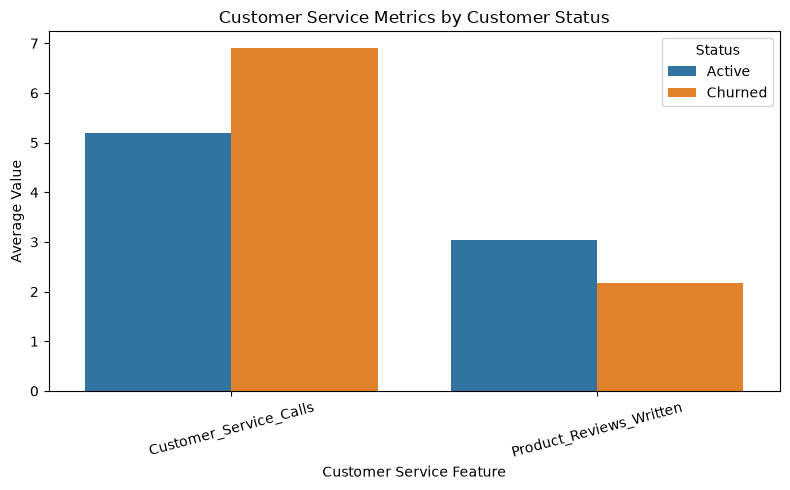

In [72]:
service_features = [
    "Customer_Service_Calls",
    "Product_Reviews_Written"
 ]

service_summary = df.groupby("Churned")[service_features].mean().T
service_summary.columns = ["Active", "Churned"]
service_summary["Difference"] = (
    service_summary["Churned"] - service_summary["Active"]
 ).round(2)

print("So sánh chỉ số chăm sóc khách hàng giữa Active và Churned:")
display(service_summary.sort_values("Difference", key=abs, ascending=False))

service_plot = service_summary[["Active", "Churned"]].reset_index()
service_plot = service_plot.rename(columns={"index": "Feature"})
service_plot = service_plot.melt(
    id_vars="Feature",
    var_name="Customer Status",
    value_name="Average Value"
 )

plt.figure(figsize=(8, 5))
sns.barplot(
    data=service_plot,
    x="Feature",
    y="Average Value",
    hue="Customer Status"
 )
plt.title("Customer Service Metrics by Customer Status")
plt.xlabel("Customer Service Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=15)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

## 11. Financial Analysis

So sánh giá trị vòng đời và số dư tín dụng giữa hai nhóm khách hàng.

So sánh chỉ số tài chính giữa Active và Churned:


,Active,Churned,Difference
Lifetime_Value,1446.805875,1425.423236,-21.38
Credit_Balance,2067.570408,1690.190450,-377.38


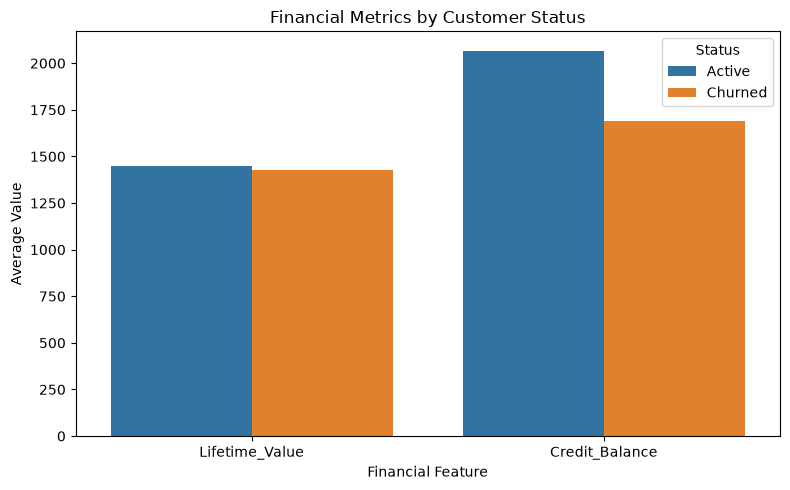

In [73]:
financial_features = [
    "Lifetime_Value",
    "Credit_Balance"
 ]

financial_summary = df.groupby("Churned")[financial_features].mean().T
financial_summary.columns = ["Active", "Churned"]
financial_summary["Difference"] = (
    financial_summary["Churned"] - financial_summary["Active"]
 ).round(2)

print("So sánh chỉ số tài chính giữa Active và Churned:")
display(financial_summary)

financial_plot = financial_summary[["Active", "Churned"]].reset_index()
financial_plot = financial_plot.rename(columns={"index": "Feature"})
financial_plot = financial_plot.melt(
    id_vars="Feature",
    var_name="Customer Status",
    value_name="Average Value"
 )

plt.figure(figsize=(8, 5))
sns.barplot(
    data=financial_plot,
    x="Feature",
    y="Average Value",
    hue="Customer Status"
 )
plt.title("Financial Metrics by Customer Status")
plt.xlabel("Financial Feature")
plt.ylabel("Average Value")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [91]:
financial_features_full = [
    "Lifetime_Value",
    "Credit_Balance",
    "Average_Order_Value"
 ]

financial_summary_full = df.groupby("Churned")[financial_features_full].mean().T
financial_summary_full.columns = ["Active", "Churned"]
financial_summary_full["Difference"] = (
    financial_summary_full["Churned"] - financial_summary_full["Active"]
 ).round(2)

print("Complete financial comparison:")
display(financial_summary_full)

Complete financial comparison:


,Active,Churned,Difference
Lifetime_Value,1446.805875,1425.423236,-21.38
Credit_Balance,2067.570408,1690.190450,-377.38
Average_Order_Value,118.383907,134.762532,16.38


## 13. Outlier Analysis

Outlier được xác định theo quy tắc IQR: giá trị nằm ngoài khoảng `Q1 - 1.5*IQR` đến `Q3 + 1.5*IQR`.

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Rate (%)
0,Session_Duration_Avg,-0.50,54.70,529,1.06
1,Average_Order_Value,0.96,230.52,1005,2.01
2,Days_Since_Last_Purchase,-36.00,84.00,2727,5.45
3,Lifetime_Value,-836.46,3500.27,1684,3.37
4,Credit_Balance,-1086.00,4914.00,578,1.16


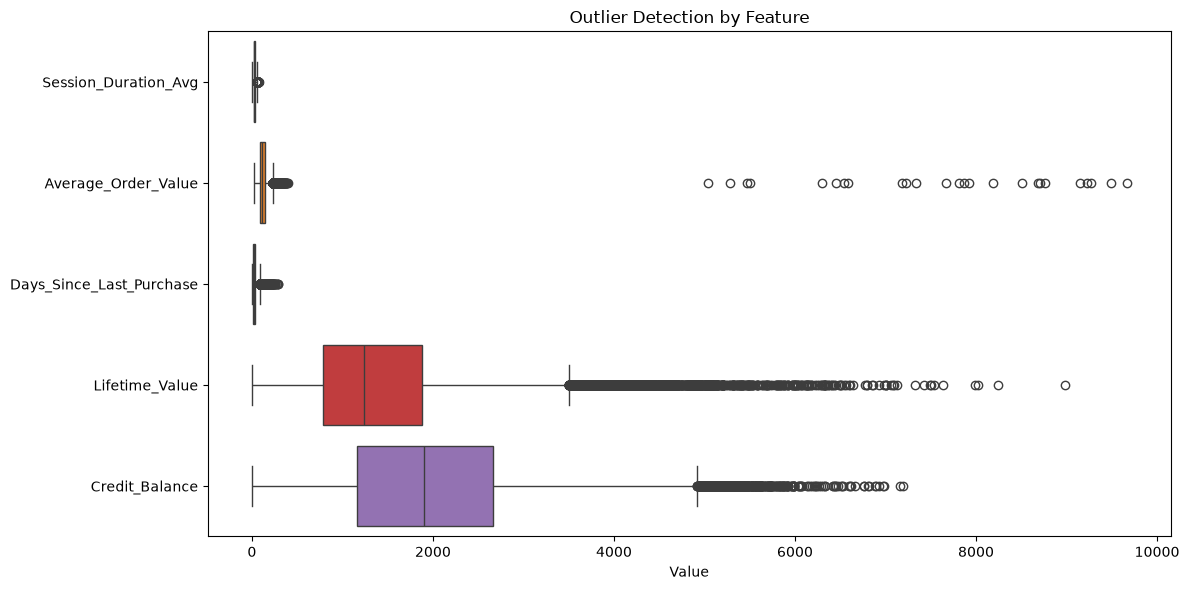

In [74]:
outlier_features = [
    "Session_Duration_Avg",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Lifetime_Value",
    "Credit_Balance"
 ]

outlier_summary = []

for feature in outlier_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ][feature].count()
    outlier_summary.append({
        "Feature": feature,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": outlier_count,
        "Outlier Rate (%)": round(outlier_count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[outlier_features], orient="h")
plt.title("Outlier Detection by Feature")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

## 12. Correlation Analysis


In [75]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

churn_corr = (
    corr["Churned"]
    .sort_values(ascending=False)
)

churn_corr

Churned                          1.000000
Customer_Service_Calls           0.290384
Cart_Abandonment_Rate            0.279465
Days_Since_Last_Purchase         0.148015
Returns_Rate                     0.051122
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004767
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.075660
Age                             -0.101901
Credit_Balance                  -0.147990
Total_Purchases                 -0.160962
Product_Reviews_Written         -0.174459
Social_Media_Engagement_Score   -0.179829
Wishlist_Items                  -0.189569
Login_Frequency                 -0.204379
Mobile_App_Usage                -0.211376
Email_Open_Rate                 -0.216233
Session_Duration_Avg            -0.219512
Pages_Per_Session               -0.224708
Name: Churned, dtype: float64

In [50]:
churn_corr.drop("Churned")

Customer_Service_Calls           0.290384
Cart_Abandonment_Rate            0.279465
Days_Since_Last_Purchase         0.148015
Returns_Rate                     0.051122
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004767
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.075660
Age                             -0.101901
Credit_Balance                  -0.147990
Total_Purchases                 -0.160962
Product_Reviews_Written         -0.174459
Social_Media_Engagement_Score   -0.179829
Wishlist_Items                  -0.189569
Login_Frequency                 -0.204379
Mobile_App_Usage                -0.211376
Email_Open_Rate                 -0.216233
Session_Duration_Avg            -0.219512
Pages_Per_Session               -0.224708
Name: Churned, dtype: float64

In [76]:
top_corr = (
    churn_corr
    .drop("Churned")
    .sort_values(key=abs, ascending=False)
    .head(10)
)

top_corr

Customer_Service_Calls           0.290384
Cart_Abandonment_Rate            0.279465
Pages_Per_Session               -0.224708
Session_Duration_Avg            -0.219512
Email_Open_Rate                 -0.216233
Mobile_App_Usage                -0.211376
Login_Frequency                 -0.204379
Wishlist_Items                  -0.189569
Social_Media_Engagement_Score   -0.179829
Product_Reviews_Written         -0.174459
Name: Churned, dtype: float64

In [90]:
correlation_without_target = churn_corr.drop("Churned")
top_positive_corr = correlation_without_target.sort_values(ascending=False).head(5)
top_negative_corr = correlation_without_target.sort_values(ascending=True).head(5)

print("Top positive correlations with Churned:")
display(top_positive_corr.to_frame("Correlation"))
print("Top negative correlations with Churned:")
display(top_negative_corr.to_frame("Correlation"))

strongest_positive_feature = top_positive_corr.index[0]
strongest_negative_feature = top_negative_corr.index[0]
print(
    f"Positive association: {strongest_positive_feature} "
    f"({top_positive_corr.iloc[0]:.3f})"
 )
print(
    f"Negative association: {strongest_negative_feature} "
    f"({top_negative_corr.iloc[0]:.3f})"
 )

Top positive correlations with Churned:


,Correlation
Customer_Service_Calls,0.290384
Cart_Abandonment_Rate,0.279465
Days_Since_Last_Purchase,0.148015
Returns_Rate,0.051122
Average_Order_Value,0.042288


Top negative correlations with Churned:


,Correlation
Pages_Per_Session,-0.224708
Session_Duration_Avg,-0.219512
Email_Open_Rate,-0.216233
Mobile_App_Usage,-0.211376
Login_Frequency,-0.204379


Positive association: Customer_Service_Calls (0.290)
Negative association: Pages_Per_Session (-0.225)


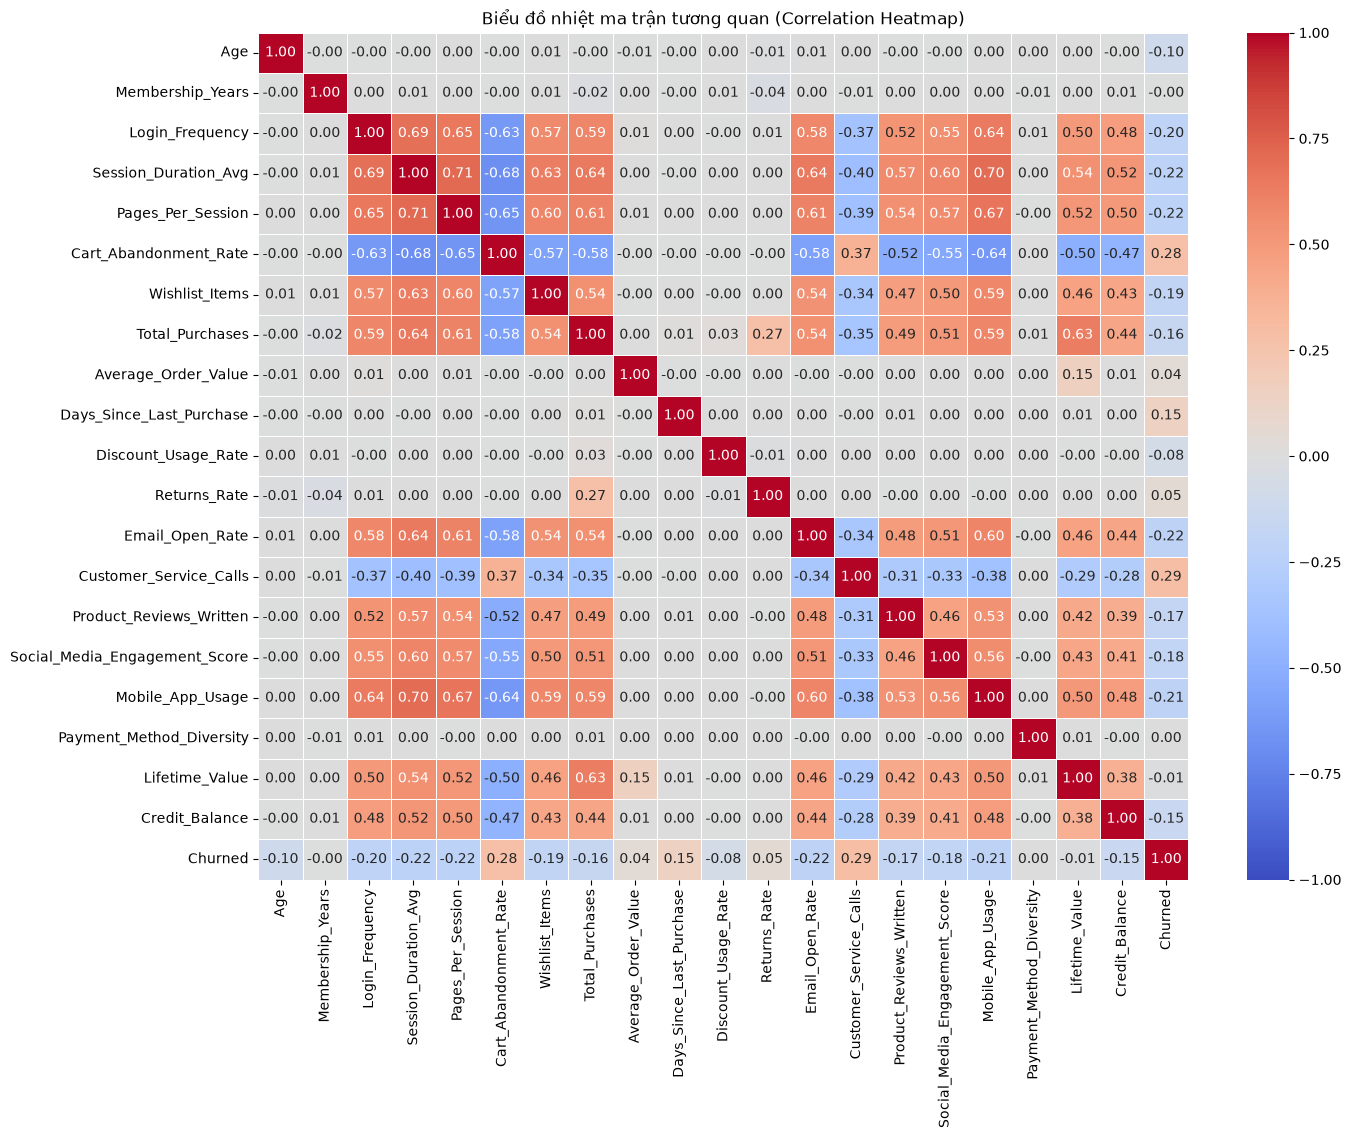

In [ ]:
corr_matrix = df.select_dtypes(include=['number', 'bool']).corr()

plt.figure(figsize=(15, 11))

sns.heatmap(
    corr_matrix, 
    annot=True,        
    cmap="coolwarm",   
    fmt=".2f",         
    linewidths=0.5,    
    vmin=-1, vmax=1    
)

plt.title("Biểu đồ nhiệt ma trận tương quan (Correlation Heatmap)")
plt.show()

## 12. Correlation Analysis

Correlation cho biết mức độ liên hệ tuyến tính giữa các biến số và `Churned`. Correlation không chứng minh quan hệ nhân quả.

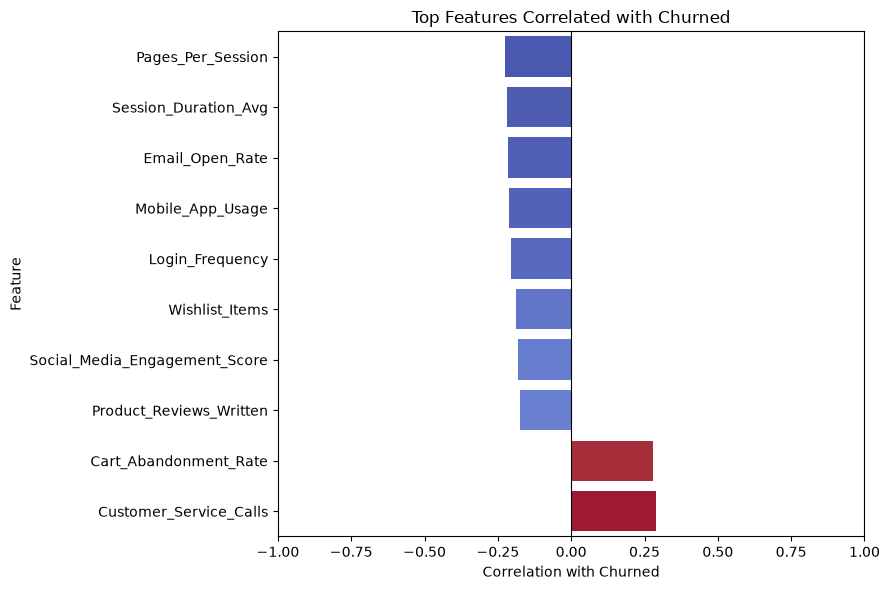

In [78]:
top_corr_plot = top_corr.reset_index()
top_corr_plot.columns = ["Feature", "Correlation"]
top_corr_plot = top_corr_plot.sort_values("Correlation")

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_corr_plot,
    x="Correlation",
    y="Feature",
    hue="Correlation",
    palette="coolwarm",
    legend=False
 )
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top Features Correlated with Churned")
plt.xlabel("Correlation with Churned")
plt.ylabel("Feature")
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

## 14. Key EDA Findings

Các kết luận dưới đây được tạo từ các bảng summary đã tính ở các phần trước.

In [81]:
overall_churn_rate = df["Churned"].mean() * 100
highest_gender = gender_churn.iloc[0]
highest_age = age_churn.loc[age_churn["Churn_Rate (%)"].idxmax()]
highest_membership = membership_yearly_summary[
    "Churn_Rate (%)"
 ].idxmax()
highest_purchase_difference = purchase_summary[
    "Difference"
 ].abs().idxmax()
highest_corr_feature = top_corr.index[0]

print(f"- Churn rate tổng thể: {overall_churn_rate:.2f}%")
print(
    f"- Quốc gia có churn rate cao nhất: "
    f"{highest_churn_country['Country']} "
    f"({highest_churn_country['Churn_Rate (%)']:.2f}%)"
 )
print(
    f"- Giới tính có churn rate cao nhất: {highest_gender['Gender']} "
    f"({highest_gender['Churn_Rate (%)']:.2f}%, "
    f"Total = {int(highest_gender['Total'])})"
 )
print(
    f"- Nhóm tuổi có churn rate cao nhất: {highest_age['Age_Group']} "
    f"({highest_age['Churn_Rate (%)']:.2f}%, "
    f"Total = {int(highest_age['Total'])})"
 )
print(
    f"- Nhóm membership có churn rate cao nhất: {highest_membership} "
    f"({membership_yearly_summary.loc[highest_membership, 'Churn_Rate (%)']:.2f}%, "
    f"Total = {int(membership_yearly_summary.loc[highest_membership, 'Total'])})"
 )
print(
    f"- Feature purchase khác biệt rõ nhất: {highest_purchase_difference} "
    f"({purchase_summary.loc[highest_purchase_difference, 'Difference']:.2f})"
 )
print(f"- Feature có correlation mạnh nhất với Churned: {highest_corr_feature}")
print("- Lưu ý: các nhóm có Total nhỏ cần được diễn giải thận trọng, không chỉ dựa vào tỷ lệ.")

- Churn rate tổng thể: 28.90%
- Quốc gia có churn rate cao nhất: Australia (29.89%)
- Giới tính có churn rate cao nhất: Other (31.27%, Total = 937)
- Nhóm tuổi có churn rate cao nhất: <=25 (45.49%, Total = 7511)
- Nhóm membership có churn rate cao nhất: 9-10 năm (29.59%, Total = 392)
- Feature purchase khác biệt rõ nhất: Average_Order_Value (16.38)
- Feature có correlation mạnh nhất với Churned: Customer_Service_Calls
- Lưu ý: các nhóm có Total nhỏ cần được diễn giải thận trọng, không chỉ dựa vào tỷ lệ.


### Detailed EDA Observations

- **Customer profile:** the highest-risk age group, country, gender and membership group should always be interpreted together with their `Total` customer count.
- **Engagement:** Churned customers have lower average login frequency, session duration, pages per session, email open rate, mobile app usage and social media engagement.
- **Purchase behavior:** Churned customers have higher cart abandonment and longer purchase recency, while they have fewer total purchases and wishlist items.
- **Customer service:** Churned customers make more customer service calls on average, while writing fewer product reviews.
- **Financial:** Churned customers have lower average lifetime value and credit balance, but higher average order value.
- **Relationship:** customer service calls and cart abandonment have the strongest positive associations with churn; pages per session, session duration and email open rate have negative associations.

## 15. Conclusion

Kết luận cuối cùng cần được diễn giải dựa trên churn rate, quy mô nhóm khách hàng, hành vi mua hàng, engagement và các feature có correlation cao. Không nên dùng correlation đơn lẻ để kết luận nguyên nhân gây churn.

In [83]:
conclusion = f"""
1. Churn rate tổng thể của tập dữ liệu là {overall_churn_rate:.2f}%.
2. {highest_churn_country['Country']} có churn rate cao nhất trong các quốc gia.
3. Nhóm tuổi {highest_age['Age_Group']} có churn rate cao nhất và cần được ưu tiên theo dõi.
4. Nhóm {highest_gender['Gender']} có churn rate cao nhất theo giới tính, nhưng cần xem cùng quy mô Total.
5. Nhóm membership {highest_membership} có tỷ lệ cao nhất, nhưng không nên kết luận chỉ từ tỷ lệ nếu quy mô nhóm nhỏ.
6. Khách hàng Churned có engagement thấp hơn và có xu hướng bỏ giỏ cao hơn, ít mua hơn và lâu quay lại hơn.
7. Các kết quả correlation cho thấy mối liên hệ, không khẳng định quan hệ nhân quả.
"""

print(conclusion)


1. Churn rate tổng thể của tập dữ liệu là 28.90%.
2. Australia có churn rate cao nhất trong các quốc gia.
3. Nhóm tuổi <=25 có churn rate cao nhất và cần được ưu tiên theo dõi.
4. Nhóm Other có churn rate cao nhất theo giới tính, nhưng cần xem cùng quy mô Total.
5. Nhóm membership 9-10 năm có tỷ lệ cao nhất, nhưng không nên kết luận chỉ từ tỷ lệ nếu quy mô nhóm nhỏ.
6. Khách hàng Churned có engagement thấp hơn và có xu hướng bỏ giỏ cao hơn, ít mua hơn và lâu quay lại hơn.
7. Các kết quả correlation cho thấy mối liên hệ, không khẳng định quan hệ nhân quả.



## Business Insights

The findings below translate the analysis into actions for customer retention:

### Insight 1 - Customer Inactivity
- Observation: Churned customers have lower login frequency, shorter sessions and lower email engagement.
- Interpretation: Reduced engagement is associated with customer churn.
- Business implication: Monitor declining activity and trigger targeted re-engagement campaigns.

### Insight 2 - Purchase Recency and Cart Abandonment
- Observation: Churned customers have higher cart abandonment and more days since their last purchase.
- Interpretation: Purchase inactivity and unfinished carts are useful early warning signals.
- Business implication: Prioritize reminders, abandoned-cart messages and win-back offers.

### Insight 3 - Customer Service
- Observation: Churned customers make more customer service calls on average.
- Interpretation: Repeated support contact is associated with possible customer friction.
- Business implication: Review recurring support issues and proactively resolve them.

### Insight 4 - Financial Value
- Observation: Churned customers have lower average credit balance and lifetime value, but higher average order value.
- Interpretation: Churn risk is not determined by order value alone.
- Business implication: Combine engagement, recency, service and financial signals when prioritizing retention.

These are observational findings. They indicate associations and do not prove that any feature causes churn.